# 3. Data Cleansing and Transformation

## 3.1 Data Cleaning and Preparation


In [1]:
import pandas as pd

df = pd.read_csv("../data/patient_data.csv")
df_original = df.copy(deep=True)

In [2]:
# Define the data cleaning function
def clean_data(data):
    clean = data.copy(deep=True)

    # Create the binary heart disease target from sublabel
    heart_disease_labels = ["HT", "DI_HT", "HT_HY", "DI_HT_HY"]
    clean["heart_disease_target"] = clean["sublabel"].isin(heart_disease_labels)

    # Remove duplicate rows
    clean = clean.drop_duplicates()

    # Reset the index after cleaning
    clean = clean.reset_index(drop=True)

    return clean

In [3]:
# Apply the cleaning function
df_clean = clean_data(df_original)

print("Original shape:", df_original.shape)
print("Cleaned shape:", df_clean.shape)
print("Rows removed:", len(df_original) - len(df_clean))

Original shape: (280985, 39)
Cleaned shape: (278701, 40)
Rows removed: 2284


In [4]:
print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nHeart disease target distribution:")
print(df_clean["heart_disease_target"].value_counts())

print("\nTarget mapping:")
print(
    pd.crosstab(
        df_clean["sublabel"],
        df_clean["heart_disease_target"]
    )
)


Duplicate rows:
0

Heart disease target distribution:
heart_disease_target
False    272810
True       5891
Name: count, dtype: int64

Target mapping:
heart_disease_target   False  True 
sublabel                           
DI                     31903      0
DI_HT                      0   1398
DI_HT_HY                   0    845
DI_HY                  66472      0
HT                         0   2583
HT_HY                      0   1065
HY                     69787      0
N                     104648      0


Duplicate removal leaves 278,701 records with no remaining duplicates. The target is highly imbalanced, with 5,891 heart disease records compared with 272,810 records without heart disease.

In [5]:
# Inspect disease related variables before deciding whether they should be retained
disease_related_columns = [
    "sublabel",
    "disease_flags",
    "label",
    "heart_disease",
    "diabetes",
    "hypertension"
]

for column in disease_related_columns:
    print(f"\n{column}")
    print(pd.crosstab(df_clean[column], df_clean["heart_disease_target"]))


sublabel
heart_disease_target   False  True 
sublabel                           
DI                     31903      0
DI_HT                      0   1398
DI_HT_HY                   0    845
DI_HY                  66472      0
HT                         0   2583
HT_HY                      0   1065
HY                     69787      0
N                     104648      0

disease_flags
heart_disease_target   False  True 
disease_flags                      
0,0,0                 104648      0
0,0,1                  69787      0
0,1,0                      0   2583
0,1,1                      0   1065
1,0,0                  31903      0
1,0,1                  66472      0
1,1,0                      0   1398
1,1,1                      0    845

label
heart_disease_target   False  True 
label                              
Abnormal              168162   5891
Normal                104648      0

heart_disease
heart_disease_target   False  True 
heart_disease                      
0.000000         

In [6]:
# Check the data types after cleaning
df_clean.dtypes

composite_key               str
age_level                   str
gender                      str
bmi_level                   str
smoking                     str
diabetes                    str
age                       int64
age_normalized          float64
bmi                     float64
hypertension            float64
heart_disease           float64
HbA1c_level             float64
glucose                 float64
cholesterol             float64
sleep_hours             float64
triglycerides           float64
physical_activity           str
family_history              str
stress_level                str
low_hdl_cholesterol         str
high_ldl_cholesterol        str
blood_pressure          float64
high_blood_pressure         str
sugar_consumption           str
crp_level               float64
homocysteine_level      float64
systolic_bp             float64
diastolic_bp            float64
alcohol_intake          float64
salt_intake             float64
heart_rate              float64
hdl     

In [7]:
# Check categorical values for formatting or inconsistent categories
categorical_columns = df_clean.select_dtypes(include=["object", "string"]).columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df_clean[column].value_counts(dropna=False))


composite_key
composite_key
Middle_Female_Overweight_Never_No      5600
Mature_Female_Overweight_Never_No      5415
Middle_Female_Obese_Never_No           5020
Mature_Female_Obese_Never_No           4986
Middle_Female_Normal_Never_No          4806
                                       ... 
Young_Female_Underweight_Current_No     184
Young_Female_Underweight_Never_Yes      176
Young_Male_Underweight_Former_Yes       175
Young_Male_Underweight_Current_Yes      161
Young_Female_Underweight_Former_Yes     147
Name: count, Length: 192, dtype: int64

age_level
age_level
Mature    87019
Middle    84478
Senior    69824
Young     37380
Name: count, dtype: int64

gender
gender
Female    147336
Male      131365
Name: count, dtype: int64

bmi_level
bmi_level
Obese          98377
Overweight     76897
Normal         70591
Underweight    32836
Name: count, dtype: int64

smoking
smoking
Never      125797
Former      80063
Current     72841
Name: count, dtype: int64

diabetes
diabetes
No     178083
Y

In [8]:
# Check numerical ranges after cleaning
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
age,278701.0,49.710381,21.682385,2.000000,32.000000,50.000000,68.000000,89.000000
age_normalized,278701.0,0.548395,0.249223,0.000000,0.344827,0.551724,0.758620,1.000000
bmi,278701.0,27.492328,7.068966,10.010000,22.010000,27.320000,32.700000,95.690000
hypertension,278701.0,0.129193,0.187602,0.000000,0.000000,0.071823,0.217063,1.000000
heart_disease,278701.0,0.073945,0.138504,0.000000,0.000000,0.007800,0.117647,1.000000
HbA1c_level,278701.0,5.951910,0.952495,3.500000,5.387500,5.800000,6.865766,9.000000
glucose,278701.0,135.267784,38.503495,70.000000,100.000000,137.000000,160.000000,300.000000
cholesterol,278701.0,224.027190,35.668600,150.000000,201.000000,225.000000,243.000000,300.000000
sleep_hours,278701.0,6.954743,1.432179,4.000000,6.196679,6.975185,7.700000,10.000000
triglycerides,278701.0,178.540442,67.344842,50.000000,128.000000,178.000000,241.750000,400.000000


In [9]:
# Inspect unusual age values
print(df_clean["age"].sort_values().head(20))

print("\nHighest BMI values:")
print(df_clean["bmi"].sort_values(ascending=False).head(20))

11860    2
11859    2
11858    2
46796    2
46795    2
46794    2
46793    2
46792    2
46791    2
46790    2
46789    2
46788    2
46787    2
46786    2
46785    2
46779    2
6916     2
6915     2
6909     2
6573     2
Name: age, dtype: int64

Highest BMI values:
54042    95.69
51824    95.22
53301    91.82
62841    88.76
69995    88.72
12015    87.70
57800    87.51
58143    83.74
46154    81.73
13786    79.48
13523    79.46
38519    75.78
25641    73.77
16583    72.89
58266    72.28
34899    72.21
91318    72.03
15193    71.55
15227    70.96
88503    69.66
Name: bmi, dtype: float64


In [10]:
# Inspect records with the minimum age
df_clean.loc[
    df_clean["age"] == df_clean["age"].min(),
    ["age", "age_level"]
].value_counts()

age  age_level
2    Young        1179
Name: count, dtype: int64

In [11]:
# Inspect the highest BMI records and their BMI categories
df_clean[
    ["bmi", "bmi_level"]
].sort_values(
    by="bmi",
    ascending=False
).head(20)

,bmi,bmi_level
54042,95.69,Obese
51824,95.22,Obese
53301,91.82,Obese
62841,88.76,Obese
69995,88.72,Obese
12015,87.70,Obese
57800,87.51,Obese
58143,83.74,Obese
46154,81.73,Obese
13786,79.48,Obese


## 3.2 Outlier Investigation and Treatment

In [12]:
# Define a function to flag potential outliers using the IQR method
def iqr_flag(series):
    # Calculate the first and third quartiles
    q1, q3 = series.quantile([0.25, 0.75])

    # Calculate the interquartile range
    iqr = q3 - q1

    # Flag values below or above the 1.5 * IQR boundaries
    return (
        (series < q1 - 1.5 * iqr)
        | (series > q3 + 1.5 * iqr)
    )

In [13]:
# Flag potential BMI outliers using the IQR method
bmi_flag = iqr_flag(df_clean["bmi"])

# Display the number of BMI values flagged as potential outliers
print("Number of BMI outliers:", bmi_flag.sum())

# Inspect the flagged records with relevant contextual variables
print(
    df_clean.loc[
        bmi_flag,
        ["age", "gender", "bmi", "bmi_level", "heart_disease_target"]
    ]
    .sort_values("bmi")
    .to_string()
)

Number of BMI outliers: 1005
       age  gender    bmi bmi_level  heart_disease_target
33499   50  Female  48.74     Obese                 False
58833   31  Female  48.75     Obese                 False
35926   22  Female  48.78     Obese                 False
92521   41    Male  48.78     Obese                 False
15865   38  Female  48.79     Obese                 False
7226    28  Female  48.80     Obese                 False
35155   54  Female  48.81     Obese                 False
92947   43    Male  48.81     Obese                 False
2941    29  Female  48.81     Obese                 False
89422   43    Male  48.82     Obese                 False
21250   47  Female  48.82     Obese                 False
80409   64    Male  48.82     Obese                  True
91397   42    Male  48.82     Obese                 False
76645   39    Male  48.82     Obese                 False
29886   56  Female  48.83     Obese                 False
10626   40  Female  48.83     Obese        

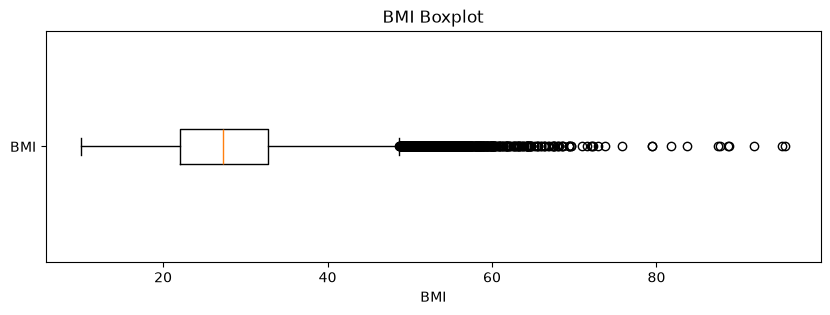

In [14]:
import matplotlib.pyplot as plt

# Create a boxplot to identify potential BMI outliers
plt.figure(figsize=(10, 3))

plt.boxplot(
    df_clean["bmi"].dropna(),
    orientation="horizontal",
    tick_labels=["BMI"]
)

plt.xlabel("BMI")
plt.title("BMI Boxplot")
plt.show()

In [15]:
print("Number of BMI outliers:", bmi_flag.sum())
# Calculate the BMI IQR boundaries
q1 = df_clean["bmi"].quantile(0.25)
q3 = df_clean["bmi"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower boundary:", lower_bound)
print("Upper boundary:", upper_bound)

Number of BMI outliers: 1005
Q1: 22.01
Q3: 32.7
IQR: 10.690000000000001
Lower boundary: 5.974999999999998
Upper boundary: 48.73500000000001


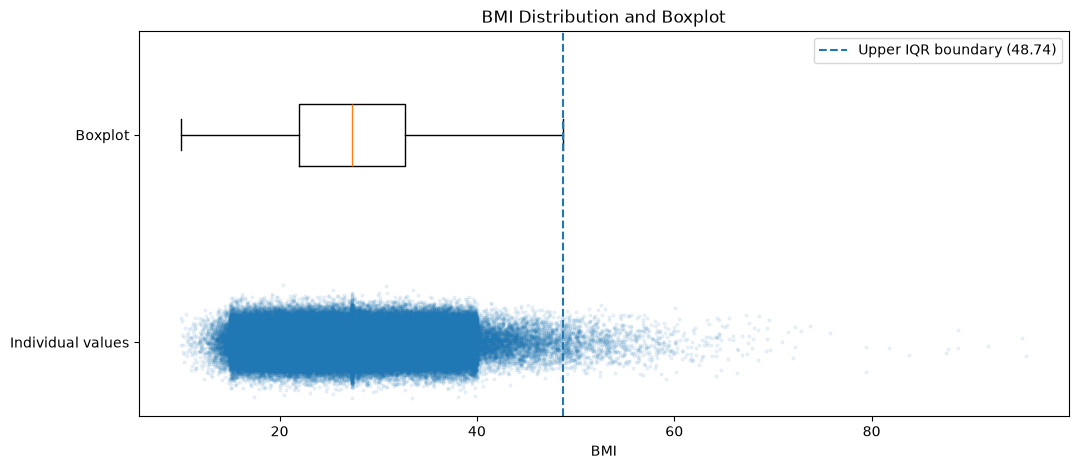

In [16]:
import numpy as np

# Set a random seed so the jitter is reproducible
np.random.seed(42)

# Create small vertical offsets for the individual observations
jitter = np.random.normal(
    loc=0,
    scale=0.06,
    size=len(df_clean)
)

# Create the figure
plt.figure(figsize=(12, 5))

# Plot all BMI observations with vertical jitter
plt.scatter(
    df_clean["bmi"],
    jitter,
    s=4,
    alpha=0.08
)

# Plot the boxplot above the individual observations
plt.boxplot(
    df_clean["bmi"].dropna(),
    orientation="horizontal",
    positions=[1],
    widths=0.3,
    showfliers=False
)

# Show the upper IQR boundary used for potential outlier detection
plt.axvline(
    upper_bound,
    linestyle="--",
    label=f"Upper IQR boundary ({upper_bound:.2f})"
)

# Label the graph
plt.yticks(
    [0, 1],
    ["Individual values", "Boxplot"]
)

plt.xlabel("BMI")
plt.title("BMI Distribution and Boxplot")
plt.legend()

plt.show()

In [17]:
# Select numerical columns for outlier checking
numerical_columns = df_clean.select_dtypes(include=["int64", "float64"]).columns

# Count potential outliers in each numerical column using the IQR method
for column in numerical_columns:
    outlier_flag = iqr_flag(df_clean[column])

    print(
        f"{column}: {outlier_flag.sum()} potential outliers"
    )

age: 0 potential outliers
age_normalized: 0 potential outliers
bmi: 1005 potential outliers
hypertension: 8060 potential outliers
heart_disease: 10051 potential outliers
HbA1c_level: 0 potential outliers
glucose: 2028 potential outliers
cholesterol: 0 potential outliers
sleep_hours: 1526 potential outliers
triglycerides: 0 potential outliers
blood_pressure: 30308 potential outliers
crp_level: 30295 potential outliers
homocysteine_level: 30989 potential outliers
systolic_bp: 27371 potential outliers
diastolic_bp: 23230 potential outliers
alcohol_intake: 32706 potential outliers
salt_intake: 33549 potential outliers
heart_rate: 20939 potential outliers
hdl: 24946 potential outliers
ldl: 29273 potential outliers


In [18]:
# Create a summary of IQR outliers for each numerical column
outlier_summary = []

for column in numerical_columns:
    # Calculate quartiles and IQR
    q1 = df_clean[column].quantile(0.25)
    q3 = df_clean[column].quantile(0.75)
    iqr = q3 - q1

    # Calculate the lower and upper IQR boundaries
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Flag potential outliers
    outlier_flag = iqr_flag(df_clean[column])
    outlier_count = outlier_flag.sum()

    # Store the results
    outlier_summary.append({
        "Column": column,
        "Min": df_clean[column].min(),
        "Lower Bound": lower_bound,
        "Q1": q1,
        "Q3": q3,
        "Upper Bound": upper_bound,
        "Max": df_clean[column].max(),
        "Outliers": outlier_count,
        "Outlier %": (outlier_count / len(df_clean)) * 100
    })

# Convert the results into a dataframe
outlier_summary_df = pd.DataFrame(outlier_summary)

# Display the summary rounded for readability
outlier_summary_df.round(2)

,Column,Min,Lower Bound,Q1,Q3,Upper Bound,Max,Outliers,Outlier %
0,age,2.00,-22.00,32.00,68.00,122.00,89.00,0,0.00
1,age_normalized,0.00,-0.28,0.34,0.76,1.38,1.00,0,0.00
2,bmi,10.01,5.97,22.01,32.70,48.74,95.69,1005,0.36
3,hypertension,0.00,-0.33,0.00,0.22,0.54,1.00,8060,2.89
4,heart_disease,0.00,-0.18,0.00,0.12,0.29,1.00,10051,3.61
5,HbA1c_level,3.50,3.17,5.39,6.87,9.08,9.00,0,0.00
6,glucose,70.00,10.00,100.00,160.00,250.00,300.00,2028,0.73
7,cholesterol,150.00,138.00,201.00,243.00,306.00,300.00,0,0.00
8,sleep_hours,4.00,3.94,6.20,7.70,9.95,10.00,1526,0.55
9,triglycerides,50.00,-42.62,128.00,241.75,412.38,400.00,0,0.00


In [19]:
# Check whether potential outliers fall below or above the IQR boundaries
outlier_direction_summary = []

for column in numerical_columns:
    # Calculate the quartiles and IQR
    q1 = df_clean[column].quantile(0.25)
    q3 = df_clean[column].quantile(0.75)
    iqr = q3 - q1

    # Calculate the lower and upper IQR boundaries
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Count values below and above the boundaries
    lower_outliers = (df_clean[column] < lower_bound).sum()
    upper_outliers = (df_clean[column] > upper_bound).sum()

    # Store the results
    outlier_direction_summary.append({
        "Column": column,
        "Lower Outliers": lower_outliers,
        "Upper Outliers": upper_outliers,
        "Total Outliers": lower_outliers + upper_outliers
    })

# Convert the results into a dataframe
outlier_direction_df = pd.DataFrame(outlier_direction_summary)

# Display the results
outlier_direction_df

,Column,Lower Outliers,Upper Outliers,Total Outliers
0,age,0,0,0
1,age_normalized,0,0,0
2,bmi,0,1005,1005
3,hypertension,0,8060,8060
4,heart_disease,0,10051,10051
5,HbA1c_level,0,0,0
6,glucose,0,2028,2028
7,cholesterol,0,0,0
8,sleep_hours,0,1526,1526
9,triglycerides,0,0,0


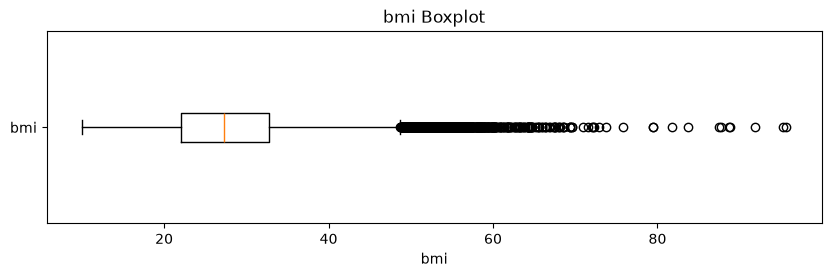

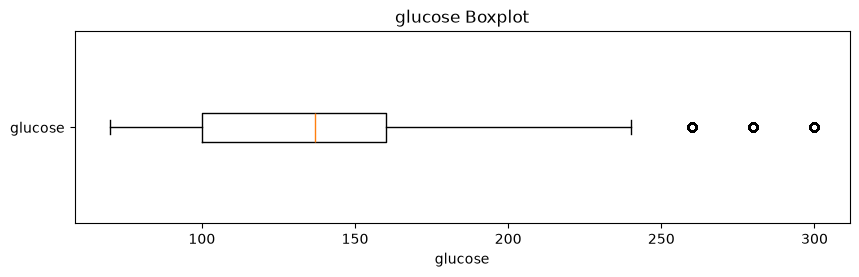

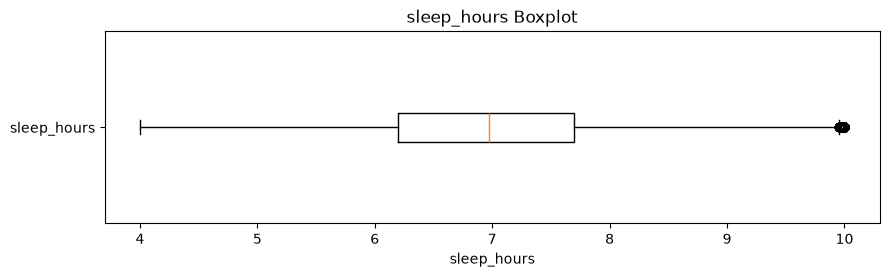

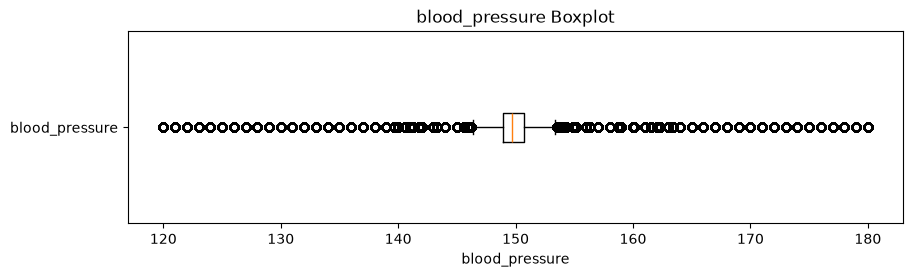

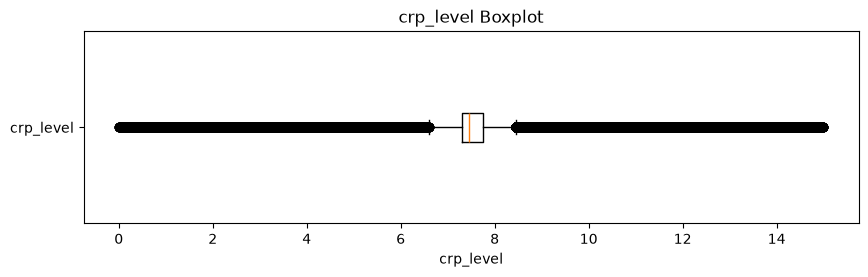

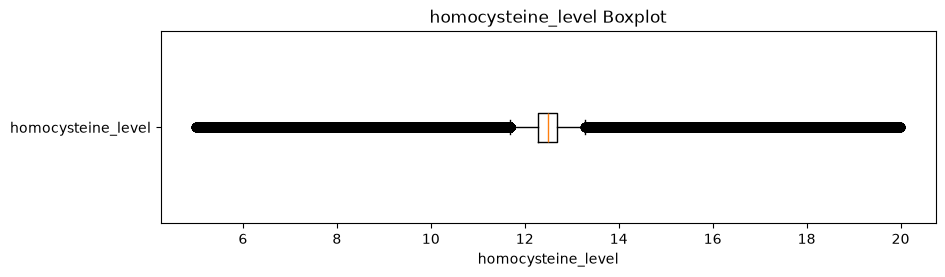

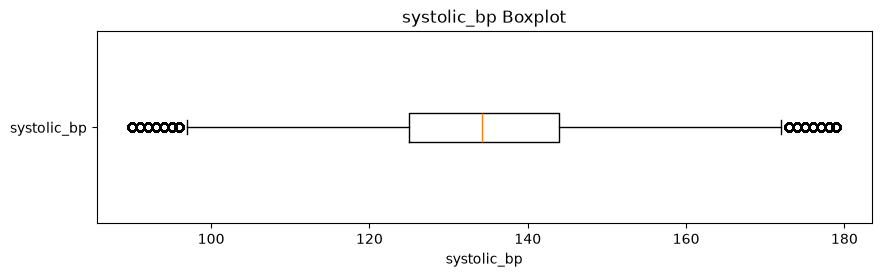

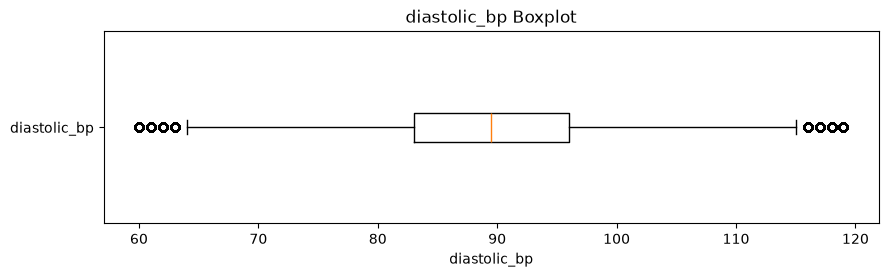

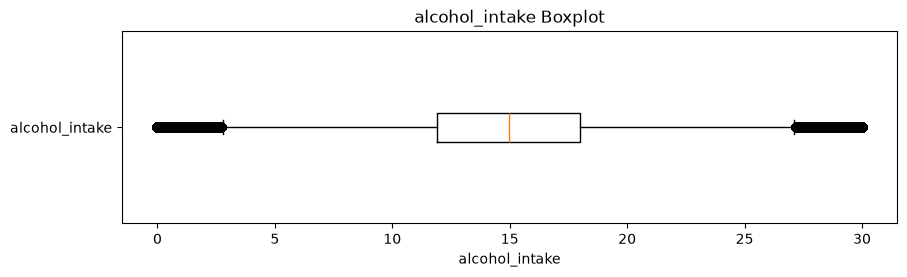

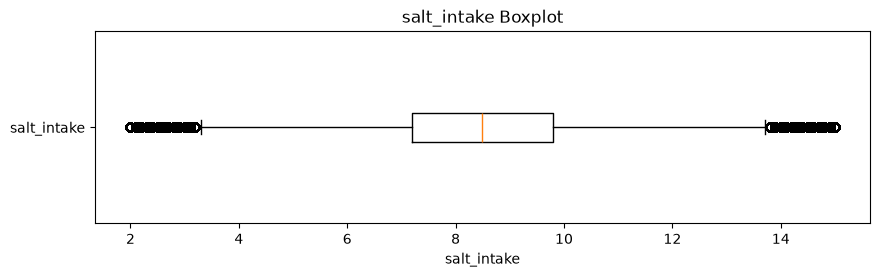

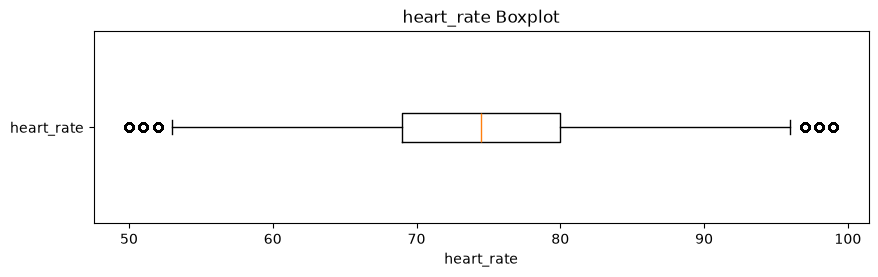

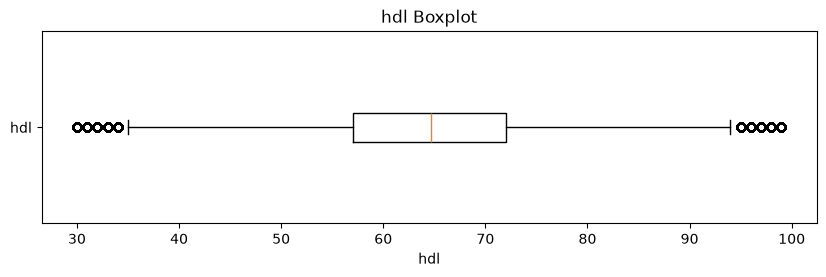

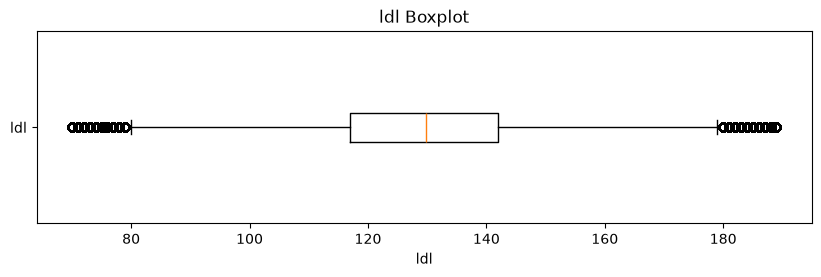

In [20]:
# Select numerical variables that had potential IQR outliers
outlier_columns = [
    "bmi",
    "glucose",
    "sleep_hours",
    "blood_pressure",
    "crp_level",
    "homocysteine_level",
    "systolic_bp",
    "diastolic_bp",
    "alcohol_intake",
    "salt_intake",
    "heart_rate",
    "hdl",
    "ldl"
]

# Create a boxplot for each variable with potential outliers
for column in outlier_columns:
    plt.figure(figsize=(10, 2.5))

    plt.boxplot(
        df_clean[column].dropna(),
        orientation="horizontal",
        tick_labels=[column]
    )

    plt.xlabel(column)
    plt.title(f"{column} Boxplot")

    plt.show()

In [21]:
# Inspect the values flagged as glucose outliers
glucose_flag = iqr_flag(df_clean["glucose"])

print("Glucose outlier values:")
print(
    df_clean.loc[glucose_flag, "glucose"]
    .value_counts()
    .sort_index()
)

# Inspect the values flagged as sleep-hour outliers
sleep_flag = iqr_flag(df_clean["sleep_hours"])

print("\nSleep hour outlier values:")
print(
    df_clean.loc[sleep_flag, "sleep_hours"]
    .value_counts()
    .sort_index()
)

Glucose outlier values:
glucose
260.0    634
280.0    722
300.0    672
Name: count, dtype: int64

Sleep hour outlier values:
sleep_hours
9.955178        1
9.955651        1
9.955790        1
9.956228        1
9.956338        1
             ... 
9.998525        1
9.998776        1
9.999151        1
9.999952        1
10.000000    1462
Name: count, Length: 65, dtype: int64


The IQR method flags potential outliers in several variables, including 1,005 BMI values and 2,028 glucose values. These values were investigated rather than automatically removed because statistical outliers are not necessarily data errors.

## 3.3 Validation of the Cleaned Dataset

In [22]:
# Compare the original and cleaned dataset dimensions
print("Original shape:", df_original.shape)
print("Cleaned shape:", df_clean.shape)

# Check for any remaining duplicate rows
print("Remaining duplicate rows:", df_clean.duplicated().sum())

# Check for missing values in the cleaned dataset
print("Total missing values:", df_clean.isnull().sum().sum())

# Display the data types after cleaning
print("\nCleaned data types:")
print(df_clean.dtypes)

Original shape: (280985, 39)
Cleaned shape: (278701, 40)
Remaining duplicate rows: 0
Total missing values: 0

Cleaned data types:
composite_key               str
age_level                   str
gender                      str
bmi_level                   str
smoking                     str
diabetes                    str
age                       int64
age_normalized          float64
bmi                     float64
hypertension            float64
heart_disease           float64
HbA1c_level             float64
glucose                 float64
cholesterol             float64
sleep_hours             float64
triglycerides           float64
physical_activity           str
family_history              str
stress_level                str
low_hdl_cholesterol         str
high_ldl_cholesterol        str
blood_pressure          float64
high_blood_pressure         str
sugar_consumption           str
crp_level               float64
homocysteine_level      float64
systolic_bp             float64
diasto

In [23]:
# Check the relationship between sublabel and the new heart disease target
target_mapping_check = pd.crosstab(
    df_clean["sublabel"],
    df_clean["heart_disease_target"]
)

print(target_mapping_check)

heart_disease_target   False  True 
sublabel                           
DI                     31903      0
DI_HT                      0   1398
DI_HT_HY                   0    845
DI_HY                  66472      0
HT                         0   2583
HT_HY                      0   1065
HY                     69787      0
N                     104648      0


In [24]:
# Compare numerical ranges before and after cleaning
numerical_columns = df_original.select_dtypes(
    include=["int64", "float64"]
).columns

range_comparison = []

for column in numerical_columns:
    # Store the minimum and maximum values before and after cleaning
    range_comparison.append({
        "Column": column,
        "Original Min": df_original[column].min(),
        "Cleaned Min": df_clean[column].min(),
        "Original Max": df_original[column].max(),
        "Cleaned Max": df_clean[column].max()
    })

# Convert the results into a dataframe
range_comparison_df = pd.DataFrame(range_comparison)

# Display the comparison
range_comparison_df

,Column,Original Min,Cleaned Min,Original Max,Cleaned Max
0,age,2.000000,2.000000,89.000000,89.000000
1,age_normalized,0.000000,0.000000,1.000000,1.000000
2,bmi,10.010000,10.010000,95.690000,95.690000
3,hypertension,0.000000,0.000000,1.000000,1.000000
4,heart_disease,0.000000,0.000000,1.000000,1.000000
5,HbA1c_level,3.500000,3.500000,9.000000,9.000000
6,glucose,70.000000,70.000000,300.000000,300.000000
7,cholesterol,150.000000,150.000000,300.000000,300.000000
8,sleep_hours,4.000000,4.000000,10.000000,10.000000
9,triglycerides,50.000000,50.000000,400.000000,400.000000


In [25]:
# Validate the cleaned dataset

# 1. Compare dataset dimensions
print("Original dataset shape:", df_original.shape)
print("Cleaned dataset shape:", df_clean.shape)


# 2. Check for remaining duplicate rows
print("\nDuplicate rows:", df_clean.duplicated().sum())


# 3. Check for remaining missing values
print("Missing values:", df_clean.isna().sum().sum())


# 4. Check the new heart disease target against sublabel
print("\nTarget mapping:")
print(
    pd.crosstab(
        df_clean["sublabel"],
        df_clean["heart_disease_target"]
    )
)


# 5. Check data types after cleaning
print("\nData types:")
print(df_clean.dtypes)


# 6. Compare numerical ranges before and after cleaning
numerical_columns = df_original.select_dtypes(
    include=["int64", "float64"]
).columns

range_comparison = []

for column in numerical_columns:
    range_comparison.append({
        "Column": column,
        "Original Min": df_original[column].min(),
        "Cleaned Min": df_clean[column].min(),
        "Original Max": df_original[column].max(),
        "Cleaned Max": df_clean[column].max()
    })

range_comparison_df = pd.DataFrame(range_comparison)

print("\nNumerical range comparison:")
display(range_comparison_df)

Original dataset shape: (280985, 39)
Cleaned dataset shape: (278701, 40)

Duplicate rows: 0
Missing values: 0

Target mapping:
heart_disease_target   False  True 
sublabel                           
DI                     31903      0
DI_HT                      0   1398
DI_HT_HY                   0    845
DI_HY                  66472      0
HT                         0   2583
HT_HY                      0   1065
HY                     69787      0
N                     104648      0

Data types:
composite_key               str
age_level                   str
gender                      str
bmi_level                   str
smoking                     str
diabetes                    str
age                       int64
age_normalized          float64
bmi                     float64
hypertension            float64
heart_disease           float64
HbA1c_level             float64
glucose                 float64
cholesterol             float64
sleep_hours             float64
triglycerides       

,Column,Original Min,Cleaned Min,Original Max,Cleaned Max
0,age,2.000000,2.000000,89.000000,89.000000
1,age_normalized,0.000000,0.000000,1.000000,1.000000
2,bmi,10.010000,10.010000,95.690000,95.690000
3,hypertension,0.000000,0.000000,1.000000,1.000000
4,heart_disease,0.000000,0.000000,1.000000,1.000000
5,HbA1c_level,3.500000,3.500000,9.000000,9.000000
6,glucose,70.000000,70.000000,300.000000,300.000000
7,cholesterol,150.000000,150.000000,300.000000,300.000000
8,sleep_hours,4.000000,4.000000,10.000000,10.000000
9,triglycerides,50.000000,50.000000,400.000000,400.000000


Final validation confirms that the cleaned dataset has 278,701 records and 40 columns, with no missing values or duplicate rows. The numerical ranges remain unchanged because valid extreme values were retained.

In [26]:
import sqlite3

# ETL: transform first, then load the cleaned result

with sqlite3.connect("../data/etl.db") as conn:
    df_clean.to_sql(
        "clean",
        conn,
        if_exists="replace",
        index=False
    )

In [27]:
print("ETL clean shape:", df_clean.shape)

with sqlite3.connect("../data/etl.db") as conn:
    print("Tables in etl.db:")
    print(
        pd.read_sql(
            "SELECT name FROM sqlite_master "
            "WHERE type='table'",
            conn
        )
    )

    stored_clean = pd.read_sql(
        "SELECT * FROM clean",
        conn
    )

    print("\nStored clean table shape:")
    print(stored_clean.shape)

ETL clean shape: (278701, 40)
Tables in etl.db:
    name
0  clean

Stored clean table shape:
(278701, 40)


In [28]:
# Save the cleaned dataset for the exploratory analysis notebook
from pathlib import Path

cleaned_data_path = Path("../data/patient_data_cleaned.csv").resolve()

if cleaned_data_path.exists():
    cleaned_data_path.unlink()

df_clean.to_csv(cleaned_data_path, index=False)

print(f"Cleaned dataset saved to: {cleaned_data_path}")
print(f"Saved shape: {df_clean.shape}")

Cleaned dataset saved to: C:\Users\yzsha\Documents\DataAndAI_project\Data-Engineering-and-AI-Project\data\patient_data_cleaned.csv
Saved shape: (278701, 40)


# Phase 2 of processing the dataset for ELCS


### 1. Removing data leakage


#### Train/test leakage

This is to split up the dataset so that only 80% of the dataset is used for training and 20% of the dataset is used for testing. The cleaning process starts off from the Phase 1 after completing validation. 

In [29]:
from sklearn.model_selection import train_test_split

# Load the cleaned dataset (output of Task 3.1–3.3 In Phase 1)
df_clean = pd.read_csv("../data/patient_data_cleaned.csv")

# Separate features and target
X = df_clean.drop(columns=["heart_disease_target"])
y = df_clean["heart_disease_target"]

# Split into train/test — stratify keeps the same class imbalance ratio in both sets so 80% train and 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (222960, 39)
Test shape: (55741, 39)

Train target distribution:
heart_disease_target
False    0.978862
True     0.021138
Name: proportion, dtype: float64

Test target distribution:
heart_disease_target
False    0.978867
True     0.021133
Name: proportion, dtype: float64


#### Target Leakage
Need to also remove columns that gives the answer or partial answer towards towards the heart_diease_target.

In [30]:
columns_to_drop = ["sublabel", "disease_flags", "heart_disease", "label"]  # All the columns to drop because it cotains information about the target 

X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

print(X_train.columns.tolist())

['composite_key', 'age_level', 'gender', 'bmi_level', 'smoking', 'diabetes', 'age', 'age_normalized', 'bmi', 'hypertension', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'blood_pressure', 'high_blood_pressure', 'sugar_consumption', 'crp_level', 'homocysteine_level', 'systolic_bp', 'diastolic_bp', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl', 'education_level', 'employment_status', 'source_dataset']


### 2. CLeaning Data

1. Checking for missing values
2. Checking duplicate records
3. Checking for invalid values
4. Checking Incosistent categories
5. Checking data types

#### Missing Values

In [31]:
#No missing values were identified during the initial Phase I inspection, and this is re-confirmed here on the split dataset. Therefore no changes were made.
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

Missing values in X_train: 0
Missing values in X_test: 0


#### Duplicate Records

2,284 duplicate records were identified and removed during Phase I cleaning From 280,985 to 278,701 records. 
But after removing the data leakage columns, there are duplicates shown.

In [32]:
# reconfirmed here for the testing and training data sets.
print("Duplicate rows in X_train:", X_train.duplicated().sum())
print("Duplicate rows in X_test:", X_test.duplicated().sum())

# Investigate whether duplicate rows have consistent or conflicting target labels
train_dupes = X_train[X_train.duplicated(keep=False)]
dupe_targets = y_train.loc[train_dupes.index].value_counts()
print("Target distribution among duplicate rows:")
print(dupe_targets)

# Show an example of a conflicting pair
example = train_dupes.sort_values(by=list(X_train.columns)).head(4)
print("\nExample of conflicting duplicate pairs:")
display(example)
print(y_train.loc[example.index])

Duplicate rows in X_train: 165
Duplicate rows in X_test: 11
Target distribution among duplicate rows:
heart_disease_target
True     165
False    165
Name: count, dtype: int64

Example of conflicting duplicate pairs:


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,...,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset
48110,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,51,0.563218,27.32,0.0,...,134.117709,89.586426,14.855673,8.508590,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes
26464,Mature_Female_Overweight_Former_No,Mature,Female,Overweight,Former,No,51,0.563218,27.32,0.0,...,134.117709,89.586426,14.855673,8.508590,74.972428,65.073171,128.567338,Secondary,Unemployed,diabetes
23489,Mature_Female_Overweight_Never_No,Mature,Female,Overweight,Never,No,47,0.517241,27.32,0.0,...,133.141732,89.136108,15.369629,8.311811,74.766029,64.934758,131.125984,Secondary,Unemployed,diabetes
28897,Mature_Female_Overweight_Never_No,Mature,Female,Overweight,Never,No,47,0.517241,27.32,0.0,...,133.141732,89.136108,15.369629,8.311811,74.766029,64.934758,131.125984,Secondary,Unemployed,diabetes


48110     True
26464    False
23489    False
28897     True
Name: heart_disease_target, dtype: bool


#### Invalid Values

The numerical variables were checked again to see if there are any plausible ranges to identify any invalid values. 
All variables (age, BMI, glucose, cholesterol, systolic and diastolic blood pressure, and heart rate) fell within medically reasonable bounds. 
No invalid or impossible values such as negative values or medically impossible values were found.

In [33]:
numeric_cols = ["age", "bmi", "glucose", "cholesterol", "systolic_bp", "diastolic_bp", "heart_rate"]
print(X_train[numeric_cols].describe())


                 age            bmi        glucose    cholesterol  \
count  222960.000000  222960.000000  222960.000000  222960.000000   
mean       49.712285      27.480704     135.341664     224.019387   
std        21.692180       7.065210      38.508772      35.663319   
min         2.000000      10.010000      70.000000     150.000000   
25%        32.000000      22.000000     100.000000     201.000000   
50%        50.000000      27.320000     138.000000     225.000000   
75%        68.000000      32.700000     160.000000     243.000000   
max        89.000000      95.220000     300.000000     300.000000   

         systolic_bp   diastolic_bp     heart_rate  
count  222960.000000  222960.000000  222960.000000  
mean      134.444033      89.479164      74.509257  
std        20.620661      13.735412      11.444668  
min        90.000000      60.000000      50.000000  
25%       125.000000      83.000000      69.000000  
50%       134.167413      89.504587      74.487247  
75%    

#### Inconsistent categories

Spelling errors, incosistent capitalisation and formating issues are reviewed by checking the unique values and frequencies of all categorical variables.
No issues were found during this review.

In [34]:
categorical_cols = X_train.select_dtypes(include=["object", "string"]).columns
for col in categorical_cols:
    print(f"\n{col}:")
    print(X_train[col].value_counts())


composite_key:
composite_key
Middle_Female_Overweight_Never_No       4502
Mature_Female_Overweight_Never_No       4355
Middle_Female_Obese_Never_No            4010
Mature_Female_Obese_Never_No            3990
Middle_Female_Normal_Never_No           3880
                                        ... 
Young_Female_Underweight_Current_Yes     148
Young_Male_Underweight_Former_Yes        144
Young_Female_Underweight_Current_No      143
Young_Male_Underweight_Current_Yes       126
Young_Female_Underweight_Former_Yes      109
Name: count, Length: 192, dtype: int64

age_level:
age_level
Mature    69626
Middle    67504
Senior    55890
Young     29940
Name: count, dtype: int64

gender:
gender
Female    117755
Male      105205
Name: count, dtype: int64

bmi_level:
bmi_level
Obese          78513
Overweight     61624
Normal         56444
Underweight    26379
Name: count, dtype: int64

smoking:
smoking
Never      100782
Former      64023
Current     58155
Name: count, dtype: int64

diabetes:
diabete

#### Data Types

The dataset's data types were reviewed and confirmed to be correct for each variable: numerical variables are stored as integers or floats, and categorical variables are stored as strings/objects. No type conversions were required.

In [35]:
print(X_train.dtypes)

composite_key               str
age_level                   str
gender                      str
bmi_level                   str
smoking                     str
diabetes                    str
age                       int64
age_normalized          float64
bmi                     float64
hypertension            float64
HbA1c_level             float64
glucose                 float64
cholesterol             float64
sleep_hours             float64
triglycerides           float64
physical_activity           str
family_history              str
stress_level                str
low_hdl_cholesterol         str
high_ldl_cholesterol        str
blood_pressure          float64
high_blood_pressure         str
sugar_consumption           str
crp_level               float64
homocysteine_level      float64
systolic_bp             float64
diastolic_bp            float64
alcohol_intake          float64
salt_intake             float64
heart_rate              float64
hdl                     float64
ldl     

### 3. Outlier



age: lower=-22.00, upper=122.00, outliers=0
bmi: lower=5.95, upper=48.75, outliers=792
glucose: lower=10.00, upper=250.00, outliers=1626
cholesterol: lower=138.00, upper=306.00, outliers=0
triglycerides: lower=-42.62, upper=412.38, outliers=0
systolic_bp: lower=96.50, upper=172.50, outliers=21879
diastolic_bp: lower=63.50, upper=115.50, outliers=18624
heart_rate: lower=52.50, upper=96.50, outliers=16803
hdl: lower=34.50, upper=94.50, outliers=20099
ldl: lower=79.50, upper=179.50, outliers=23426


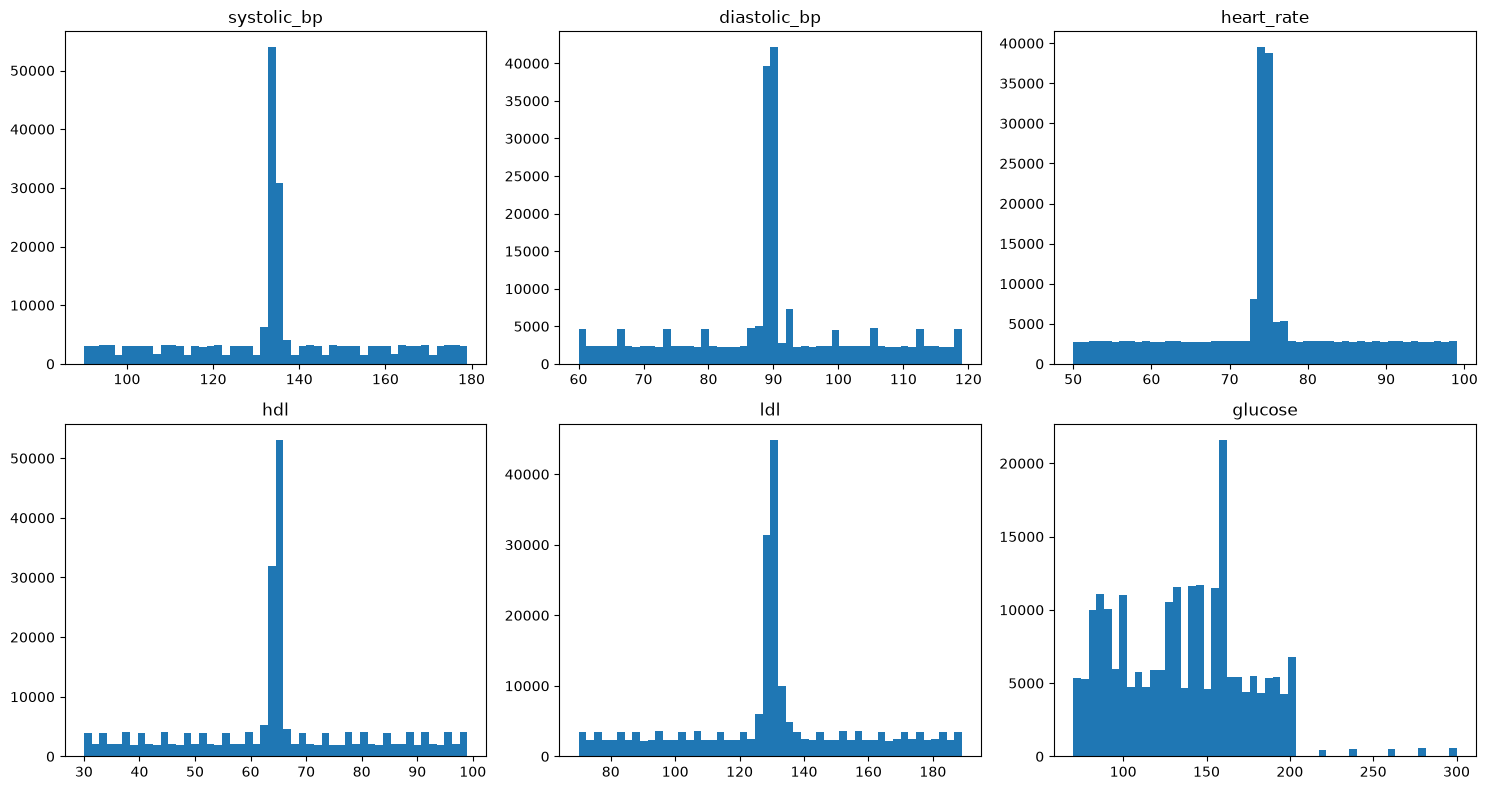

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Using IQR to check for outliers, so and values that is below the lower range and any values that are above the upper range is identified as an outlier.
def iqr_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return lower, upper, len(outliers)

numeric_cols = ["age", "bmi", "glucose", "cholesterol", "triglycerides",
                "systolic_bp", "diastolic_bp", "heart_rate", "hdl", "ldl"]

for col in numeric_cols:
    lower, upper, n = iqr_outliers(X_train, col)
    print(f"{col}: lower={lower:.2f}, upper={upper:.2f}, outliers={n}")

# Create historgrams for the numerical columns to see the distrubtion of data.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols_to_check = ["systolic_bp", "diastolic_bp", "heart_rate", "hdl", "ldl", "glucose"]

for ax, col in zip(axes.flatten(), cols_to_check):
    ax.hist(X_train[col], bins=50)
    ax.set_title(col)

plt.tight_layout()
plt.show()



### 4. Feature engineering / selection / dimensionality reduction

Removing composite_key, age_level, age_normlaize and bmi columns because 

In [37]:
columns_to_drop = ["composite_key", "age_level", "age_normalized", "bmi"]

X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

print("Remaining columns:", X_train.columns.tolist())
print("Shape:", X_train.shape)

Remaining columns: ['gender', 'bmi_level', 'smoking', 'diabetes', 'age', 'hypertension', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'physical_activity', 'family_history', 'stress_level', 'low_hdl_cholesterol', 'high_ldl_cholesterol', 'blood_pressure', 'high_blood_pressure', 'sugar_consumption', 'crp_level', 'homocysteine_level', 'systolic_bp', 'diastolic_bp', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl', 'education_level', 'employment_status', 'source_dataset']
Shape: (222960, 31)


### 6. Encoding categorical variable

Encoding the:
1. binary column (gender, diabetes, family_history, low_hdl_cholesterol, high_ldl_cholesterol, high_blood_pressure),
2. ordinal column (bmi_level, smoking, physical_activity, stress_level, sugar_consumption, education_level) and
3. nominant column (employment_status, source_dataset)

In [38]:
# Binary encoding
binary_maps = {
    "gender": {"Female": 0, "Male": 1},
    "diabetes": {"No": 0, "Yes": 1},
    "family_history": {"No": 0, "Yes": 1},
    "low_hdl_cholesterol": {"No": 0, "Yes": 1},
    "high_ldl_cholesterol": {"No": 0, "Yes": 1},
    "high_blood_pressure": {"No": 0, "Yes": 1},
}
for col, mapping in binary_maps.items():
    X_train[col] = X_train[col].map(mapping)
    X_test[col] = X_test[col].map(mapping)

# Ordinal encoding
from sklearn.preprocessing import OrdinalEncoder

ordinal_cols = ["bmi_level", "smoking", "physical_activity", "stress_level",
                "sugar_consumption", "education_level"]
ordinal_categories = [
    ["Underweight", "Normal", "Overweight", "Obese"],
    ["Never", "Former", "Current"],
    ["Low", "Moderate", "High"],
    ["Low", "Medium", "High"],
    ["Low", "Medium", "High"],
    ["Primary", "Secondary", "Tertiary"],
]

enc = OrdinalEncoder(categories=ordinal_categories)
X_train[ordinal_cols] = enc.fit_transform(X_train[ordinal_cols])  # fit on train only
X_test[ordinal_cols] = enc.transform(X_test[ordinal_cols])         # apply to test

# One-hot encoding for nominal columns — dtype=int gives 0/1 directly instead of True/False
nominal_cols = ["employment_status", "source_dataset"]
X_train = pd.get_dummies(X_train, columns=nominal_cols, dtype=int)
X_test = pd.get_dummies(X_test, columns=nominal_cols, dtype=int)

# Align test columns to train (in case any category is missing from one split)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X_train.head()

X_train shape: (222960, 35)
X_test shape: (55741, 35)


,gender,bmi_level,smoking,diabetes,age,hypertension,HbA1c_level,glucose,cholesterol,sleep_hours,...,heart_rate,hdl,ldl,education_level,employment_status_Employed,employment_status_Retired,employment_status_Unemployed,source_dataset_diabetes,source_dataset_heart,source_dataset_hypertension
31257,0,3.0,0.0,0,58,1.000000,5.800000,155.0,223.07027,7.037577,...,74.754963,64.573454,128.362450,2.0,0,1,0,1,0,0
122755,1,2.0,0.0,1,36,0.113402,6.786598,170.0,154.00000,8.000000,...,53.000000,61.000000,188.000000,2.0,0,0,1,0,0,1
162764,0,3.0,0.0,0,85,0.217063,5.408747,183.0,261.00000,5.800000,...,55.000000,58.000000,149.000000,2.0,1,0,0,0,0,1
2022,0,0.0,0.0,0,25,0.000000,3.500000,158.0,228.80000,5.485538,...,74.770393,64.634441,129.706949,2.0,0,0,1,1,0,0
249582,0,3.0,1.0,0,32,0.050150,5.413942,81.0,224.00000,7.500000,...,84.000000,50.000000,153.000000,0.0,1,0,0,0,0,1


In [39]:
# List of columns that were encoded
binary_cols = ["gender", "diabetes", "family_history", "low_hdl_cholesterol",
               "high_ldl_cholesterol", "high_blood_pressure"]

ordinal_cols = ["bmi_level", "smoking", "physical_activity", "stress_level",
                "sugar_consumption", "education_level"]

onehot_cols = [col for col in X_train.columns if col.startswith("employment_status_") or col.startswith("source_dataset_")]

encoded_cols = binary_cols + ordinal_cols + onehot_cols

X_train[encoded_cols].head().T

,31257,122755,162764,2022,249582
gender,0.0,1.0,0.0,0.0,0.0
diabetes,0.0,1.0,0.0,0.0,0.0
family_history,0.0,0.0,1.0,0.0,0.0
low_hdl_cholesterol,0.0,0.0,0.0,0.0,0.0
high_ldl_cholesterol,0.0,1.0,1.0,0.0,1.0
high_blood_pressure,0.0,1.0,0.0,0.0,1.0
bmi_level,3.0,2.0,3.0,0.0,3.0
smoking,0.0,0.0,0.0,0.0,1.0
physical_activity,0.0,1.0,1.0,2.0,1.0
stress_level,2.0,0.0,2.0,1.0,2.0


### 7.  Scaling/discretising/transforming numerical variables

#### Discretisation



In [40]:
import pandas as pd
import numpy as np

# Features that have a set standard (clinical standard)

def discretise_glucose(x):
    return pd.cut(x, bins=[-np.inf, 100, 126, np.inf],
                   labels=["Normal", "Prediabetes", "Diabetes"])

def discretise_cholesterol(x):
    return pd.cut(x, bins=[-np.inf, 200, 240, np.inf],
                   labels=["Desirable", "Borderline", "High"])

def discretise_systolic(x):
    return pd.cut(x, bins=[-np.inf, 120, 130, 140, np.inf],
                   labels=["Normal", "Elevated", "Stage1", "Stage2"])

def discretise_diastolic(x):
    return pd.cut(x, bins=[-np.inf, 80, 90, np.inf],
                   labels=["Normal", "Stage1", "Stage2"])

def discretise_hba1c(x):
    return pd.cut(x, bins=[-np.inf, 5.7, 6.5, np.inf],
                   labels=["Normal", "Prediabetes", "Diabetes"])

def discretise_age(x):
    return pd.cut(x, bins=[-np.inf, 18, 40, 60, np.inf],
                   labels=["Child", "YoungAdult", "MiddleAged", "Senior"])

def discretise_triglycerides(x):
    return pd.cut(x, bins=[-np.inf, 150, 200, 500, np.inf],
                   labels=["Normal", "BorderlineHigh", "High", "VeryHigh"])

def discretise_hdl(x):
    return pd.cut(x, bins=[-np.inf, 40, 60, np.inf],
                   labels=["Low", "Normal", "High"])

def discretise_ldl(x):
    return pd.cut(x, bins=[-np.inf, 100, 130, 160, 190, np.inf],
                   labels=["Optimal", "NearOptimal", "BorderlineHigh", "High", "VeryHigh"])

def discretise_heart_rate(x):
    return pd.cut(x, bins=[-np.inf, 60, 100, np.inf],
                   labels=["Low", "Normal", "High"])

def discretise_crp(x):
    return pd.cut(x, bins=[-np.inf, 1, 3, np.inf],
                   labels=["Low", "Average", "High"])

def discretise_sleep(x):
    return pd.cut(x, bins=[-np.inf, 7, 9, np.inf],
                   labels=["Short", "Recommended", "Long"])

def discretise_homocysteine(x):
    return pd.cut(x, bins=[-np.inf, 15, 30, np.inf],
                   labels=["Normal", "Elevated", "High"])

domain_binned_cols = {
    "glucose": discretise_glucose,
    "cholesterol": discretise_cholesterol,
    "systolic_bp": discretise_systolic,
    "diastolic_bp": discretise_diastolic,
    "HbA1c_level": discretise_hba1c,
    "age": discretise_age,
    "triglycerides": discretise_triglycerides,
    "hdl": discretise_hdl,
    "ldl": discretise_ldl,
    "heart_rate": discretise_heart_rate,
    "crp_level": discretise_crp,
    "sleep_hours": discretise_sleep,
    "homocysteine_level": discretise_homocysteine,
}

for col, func in domain_binned_cols.items():
    X_train[col + "_binned"] = func(X_train[col])
    X_test[col + "_binned"] = func(X_test[col])

# Quantile-based discretisation (because there are no set standard)

quantile_cols = ["hypertension", "alcohol_intake", "salt_intake"]

for col in quantile_cols:
    _, bin_edges = pd.qcut(X_train[col], q=3, retbins=True, duplicates="drop")
    bin_edges[0] = -np.inf
    bin_edges[-1] = np.inf

    X_train[col + "_binned"] = pd.cut(X_train[col], bins=bin_edges,
                                        labels=["Low", "Medium", "High"][:len(bin_edges)-1],
                                        include_lowest=True)
    X_test[col + "_binned"] = pd.cut(X_test[col], bins=bin_edges,
                                       labels=["Low", "Medium", "High"][:len(bin_edges)-1],
                                       include_lowest=True)

print(X_train.filter(like="_binned").isnull().sum())
print(X_test.filter(like="_binned").isnull().sum())
print(X_train.filter(like="_binned").head())

glucose_binned               0
cholesterol_binned           0
systolic_bp_binned           0
diastolic_bp_binned          0
HbA1c_level_binned           0
age_binned                   0
triglycerides_binned         0
hdl_binned                   0
ldl_binned                   0
heart_rate_binned            0
crp_level_binned             0
sleep_hours_binned           0
homocysteine_level_binned    0
hypertension_binned          0
alcohol_intake_binned        0
salt_intake_binned           0
dtype: int64
glucose_binned               0
cholesterol_binned           0
systolic_bp_binned           0
diastolic_bp_binned          0
HbA1c_level_binned           0
age_binned                   0
triglycerides_binned         0
hdl_binned                   0
ldl_binned                   0
heart_rate_binned            0
crp_level_binned             0
sleep_hours_binned           0
homocysteine_level_binned    0
hypertension_binned          0
alcohol_intake_binned        0
salt_intake_binned        

#### Encoding numerical variables

Since tie numercail variables have been turned into categorical variables these would then need to be encoded.

In [41]:
from sklearn.preprocessing import OrdinalEncoder

binned_ordinal_categories = {
    "glucose_binned": ["Normal", "Prediabetes", "Diabetes"],
    "cholesterol_binned": ["Desirable", "Borderline", "High"],
    "systolic_bp_binned": ["Normal", "Elevated", "Stage1", "Stage2"],
    "diastolic_bp_binned": ["Normal", "Stage1", "Stage2"],
    "HbA1c_level_binned": ["Normal", "Prediabetes", "Diabetes"],
    "age_binned": ["Child", "YoungAdult", "MiddleAged", "Senior"],
    "triglycerides_binned": ["Normal", "BorderlineHigh", "High", "VeryHigh"],
    "hdl_binned": ["Low", "Normal", "High"],
    "ldl_binned": ["Optimal", "NearOptimal", "BorderlineHigh", "High", "VeryHigh"],
    "heart_rate_binned": ["Low", "Normal", "High"],
    "crp_level_binned": ["Low", "Average", "High"],
    "sleep_hours_binned": ["Short", "Recommended", "Long"],
    "homocysteine_level_binned": ["Normal", "Elevated", "High"],
    "hypertension_binned": ["Low", "Medium", "High"],
    "alcohol_intake_binned": ["Low", "Medium", "High"],
    "salt_intake_binned": ["Low", "Medium", "High"],
}

binned_cols = list(binned_ordinal_categories.keys())
categories_list = list(binned_ordinal_categories.values())

enc_binned = OrdinalEncoder(categories=categories_list)
X_train[binned_cols] = enc_binned.fit_transform(X_train[binned_cols])
X_test[binned_cols] = enc_binned.transform(X_test[binned_cols])

print(X_train[binned_cols].head())

        glucose_binned  cholesterol_binned  systolic_bp_binned  \
31257              2.0                 1.0                 2.0   
122755             2.0                 0.0                 0.0   
162764             2.0                 2.0                 0.0   
2022               2.0                 1.0                 2.0   
249582             0.0                 1.0                 0.0   

        diastolic_bp_binned  HbA1c_level_binned  age_binned  \
31257                   1.0                 1.0         2.0   
122755                  0.0                 2.0         1.0   
162764                  0.0                 0.0         3.0   
2022                    1.0                 0.0         1.0   
249582                  0.0                 0.0         1.0   

        triglycerides_binned  hdl_binned  ldl_binned  heart_rate_binned  \
31257                    2.0         2.0         1.0                1.0   
122755                   0.0         2.0         3.0                0.0   

In [42]:
# Drop the original raw numeric columns replaced with the binned+encoded version
raw_cols_to_drop = ["glucose", "cholesterol", "systolic_bp", "diastolic_bp", "HbA1c_level",
                     "age", "triglycerides", "heart_rate", "hdl", "ldl", "hypertension",
                     "crp_level", "homocysteine_level", "alcohol_intake", "salt_intake", "sleep_hours"]

X_train = X_train.drop(columns=raw_cols_to_drop)
X_test = X_test.drop(columns=raw_cols_to_drop)

print("Final X_train shape:", X_train.shape)
print("Final X_test shape:", X_test.shape)
print(X_train.dtypes.value_counts())  # confirm everything is now numeric

Final X_train shape: (222960, 35)
Final X_test shape: (55741, 35)
float64    23
int64      12
Name: count, dtype: int64


In [45]:
from pathlib import Path

output_dir = Path("../data")
output_dir.mkdir(parents=True, exist_ok=True)

X_train.to_csv(output_dir / "X_train_preprocessed.csv", index=False)
X_test.to_csv(output_dir / "X_test_preprocessed.csv", index=False)
y_train.to_csv(output_dir / "y_train_preprocessed.csv", index=False)
y_test.to_csv(output_dir / "y_test_preprocessed.csv", index=False)

print("Saved preprocessed train/test sets to:", output_dir.resolve())
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Saved preprocessed train/test sets to: C:\Users\yzsha\Documents\DataAndAI_project\Data-Engineering-and-AI-Project\data
X_train shape: (222960, 35)
X_test shape: (55741, 35)
